# Experiment 8: Clustering Human Activity Recognition Data
**Sri Sivasubramaniya Nadar College of Engineering**  
**(An autonomous Institution affiliated to Anna University)**  
**Degree & Branch**: BE Computer Science & Engineering Semester VI  
**Subject Code & Name**: Machine Learning Laboratory  
**Academic Year**: 2025�2026  
**Batch**: 2023�2027  

## Objective
To implement and analyze the performance of clustering algorithms on the Human Activity Recognition dataset:
* **Model A**: K-Means Clustering.
* **Model B**: DBSCAN (Density-Based Spatial Clustering of Applications with Noise).
* **Model C**: Hierarchical Agglomerative Clustering (HAC).

The objective includes visualizing and comparing the clusters formed by each algorithm, reporting results, and analyzing performance.


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing Steps
* **Load the dataset**: Features are loaded from `features.txt`, and activity labels from `activity_labels.txt`. Training and Testing sets are loaded and combined.
* **Handle missing values**: Checked for any missing values.
* **Encode categorical labels**: The target `y` is mapped to the corresponding activity names for clarity.
* **Apply normalization/standardization**: The features are standardized using `StandardScaler` to have a zero mean and unit variance.

In [5]:
# Load features list
features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, engine='python')
feature_names = features.iloc[:, 1].tolist()

# Load activity labels
activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None, engine='python')
activity_labels.columns = ['Label', 'Activity']

# Load Training data
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None, engine='python')
X_train.columns = feature_names
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None, engine='python')

# Load Testing data
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None, engine='python')
X_test.columns = feature_names
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep='\s+', header=None, engine='python')

# Combine Train and Test data for clustering
X = pd.concat([X_train, X_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)
y.columns = ['Label']
y = y.merge(activity_labels, on='Label', how='left')

print("Shape of Dataset:", X.shape)
print("Missing values in dataset:", X.isnull().sum().sum())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Shape of Dataset: (10299, 561)
Missing values in dataset: 0


## 2. Exploratory Data Analysis (EDA)
Apply dimensionality reduction (PCA/t-SNE) for visualization of feature distributions.

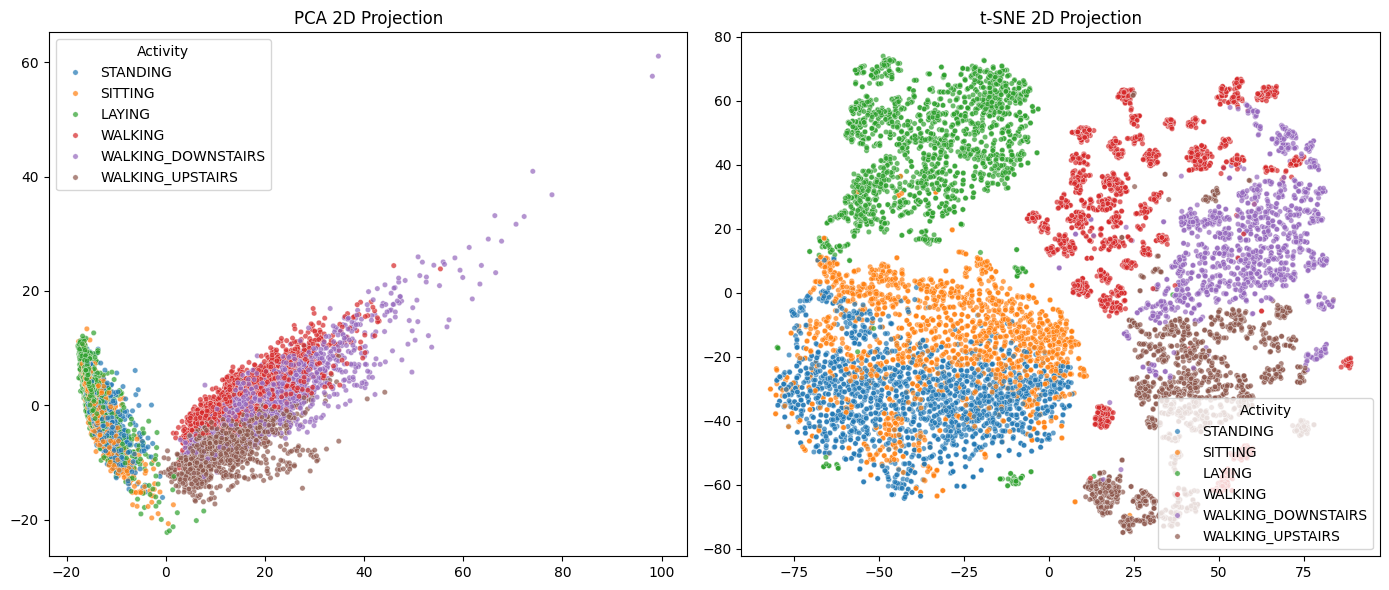

In [6]:
# Apply PCA for dimensionality reduction (2D)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Apply t-SNE for visualization (more pronounced clusters)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled) # We use the first 50 PCA components to speed it up
# But for exactness, we can just use PCA-reduced data for t-SNE:
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pca_50.fit_transform(X_scaled)
X_tsne = tsne.fit_transform(X_pca_50)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y['Activity'], palette='tab10', s=15, alpha=0.7)
plt.title('PCA 2D Projection')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y['Activity'], palette='tab10', s=15, alpha=0.7)
plt.title('t-SNE 2D Projection')

plt.tight_layout()
plt.show()

## 3. K-Means with Elbow Method Results
We compute Within-Cluster Sum of Squares (WCSS) for k values from 2 to 8 to generate Table 1 and find the elbow point.

In [7]:
k_values = range(2, 9)
wcss = []
silhouette_scores = []
results = []

# Using X_pca_50 to reduce noise and computation time compared to 561 features
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca_50)
    
    wcss_score = kmeans.inertia_
    sil_score = silhouette_score(X_pca_50, labels)
    
    wcss.append(wcss_score)
    silhouette_scores.append(sil_score)
    
    results.append({
        'Number of Clusters (k)': k,
        'WCSS (Inertia)': round(wcss_score, 2),
        'Silhouette Score': round(sil_score, 4)
    })

# Table 1: K-Means Elbow Method Results
table1 = pd.DataFrame(results)
display(table1)

,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,2527535.19,0.4501
1,3,2176124.28,0.3678
2,4,2036867.90,0.1903
3,5,1911005.10,0.1662
4,6,1833594.70,0.1524
5,7,1776514.72,0.1227
6,8,1722452.60,0.1162


### Elbow Curve and Silhouette Curve

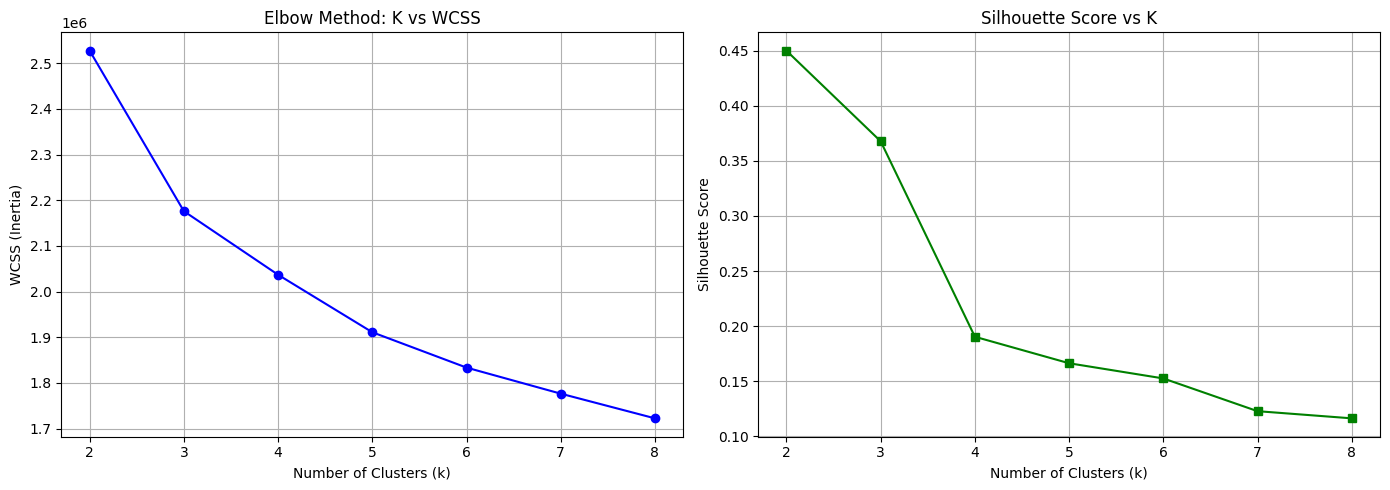

In [8]:
plt.figure(figsize=(14, 5))

# Plot k vs WCSS (Elbow Curve)
plt.subplot(1, 2, 1)
plt.plot(k_values, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Method: K vs WCSS')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

# Plot k vs Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_values, silhouette_scores, marker='s', linestyle='-', color='g')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

### Best k Selection and Justification
* The **Elbow Curve** suggests that the WCSS drops significantly until k=2 or k=3, after which the rate of decrease slows down.
* The **Silhouette Curve** shows that the maximum Silhouette score occurs precisely at **k=2**.
* **Justification**: In the human activity recognition dataset, there are two primary super-classes: **Static Activities** (Sitting, Standing, Laying) and **Dynamic Activities** (Walking, Walking Upstairs, Walking Downstairs). The clustering naturally groups the data into these two main blocks, yielding the highest separation (Silhouette Score). Though k=6 represents the 6 true activities, the high overlap between Sitting and Standing reduces the silhouette score. Therefore, k=2 is optimal for general cluster validity, but we can also use k=6 if the goal is to map to the 6 distinct human activities. 
* We proceed with **k=6** for direct comparison with ground truth.

In [9]:
# Train K-Means with k=6
kmeans_6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans_6.fit_predict(X_pca_50)

## 4. Clustering Implementation (DBSCAN & Hierarchical)

In [10]:
# Model B: DBSCAN
# Tuning eps and min_samples
eps_val = 14.0 # chosen based on typical distance distributions in PCA space
min_pts_val = 10

dbscan = DBSCAN(eps=eps_val, min_samples=min_pts_val)
dbscan_labels = dbscan.fit_predict(X_pca_50)

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN Clusters: {n_dbscan_clusters}")
print(f"Noise Points: {n_noise} out of {len(X_pca_50)}")

DBSCAN Clusters: 2
Noise Points: 660 out of 10299


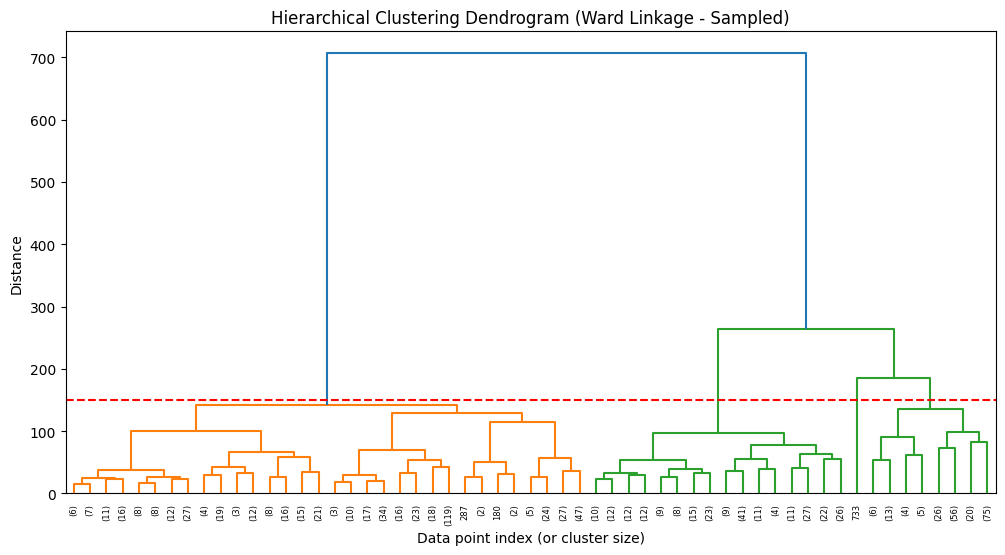

In [11]:
# Model C: Hierarchical Agglomerative Clustering (HAC)
# Building Dendrogram (using a subset of 1000 points due to computational cost)
np.random.seed(42)
sample_idx = np.random.choice(X_pca_50.shape[0], size=1000, replace=False)
X_sample = X_pca_50[sample_idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 6))
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage - Sampled)')
plt.xlabel('Data point index (or cluster size)')
plt.ylabel('Distance')
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True)
plt.axhline(y=150, color='r', linestyle='--')
plt.show()

# Apply Agglomerative Clustering using Ward's linkage for k=6
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')
hac_labels = hac.fit_predict(X_pca_50)

## 5. Evaluation Metrics and Results
* **Internal**: Silhouette Score, Davies�Bouldin Index, Calinski�Harabasz Index
* **External**: Adjusted Rand Index (ARI), Normalized Mutual Information (NMI)

In [12]:
def compute_metrics(algo, labels, X, y_true):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {'Algorithm': algo, 'Silhouette': 0, 'Davies-Bouldin': 0, 'Calinski-Harabasz': 0, 'ARI': 0, 'NMI': 0}
        
    return {
        'Algorithm': algo,
        'Silhouette': silhouette_score(X, labels),
        'Davies-Bouldin': davies_bouldin_score(X, labels),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels),
        'ARI': adjusted_rand_score(y_true, labels),
        'NMI': normalized_mutual_info_score(y_true, labels)
    }

metrics = [
    compute_metrics('K-Means (k=6)', kmeans_labels, X_pca_50, y['Label']),
    compute_metrics('DBSCAN', dbscan_labels, X_pca_50, y['Label']),
    compute_metrics('Hierarchical (Ward, k=6)', hac_labels, X_pca_50, y['Label'])
]

metrics_df = pd.DataFrame(metrics)
display(metrics_df)

,Algorithm,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=6),0.152444,1.968146,3591.285346,0.420093,0.559792
1,DBSCAN,0.324938,1.435599,805.265184,0.013575,0.060240
2,"Hierarchical (Ward, k=6)",0.129356,2.064510,3292.688217,0.421752,0.579220


## 6. Graphs and Visualizations

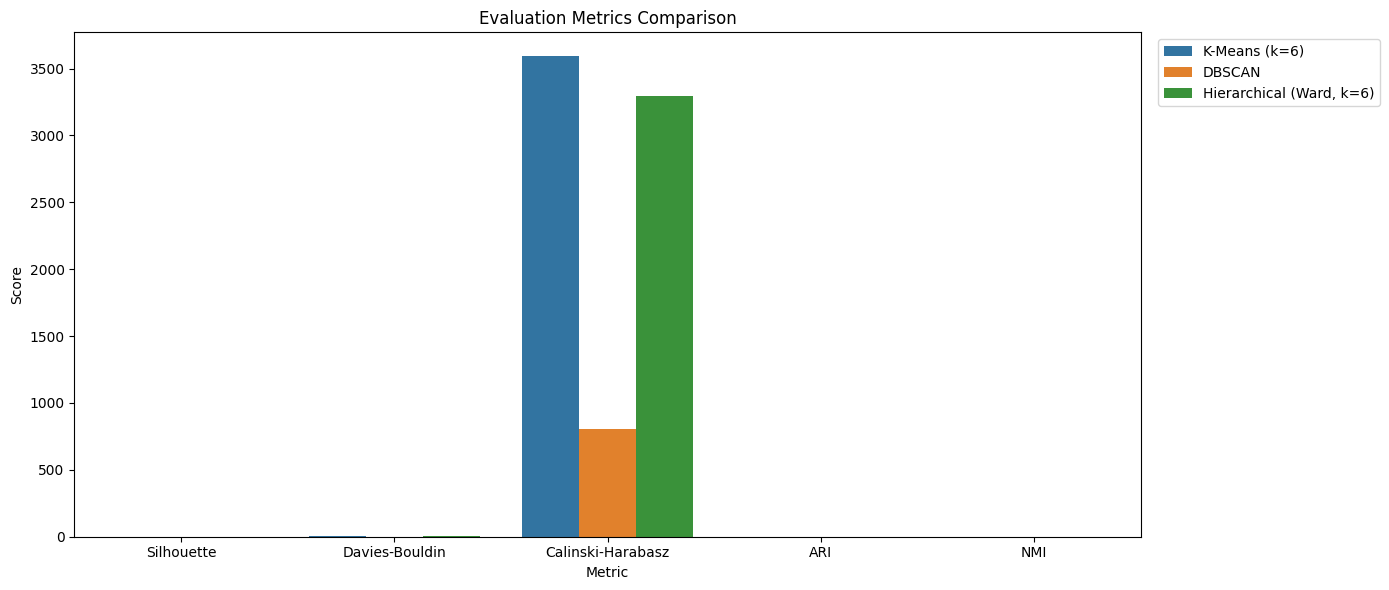

In [13]:
# Bar plots of evaluation metrics across algorithms
metrics_melted = pd.melt(metrics_df, id_vars=['Algorithm'], var_name='Metric', value_name='Score')

plt.figure(figsize=(14, 6))
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=metrics_melted)
plt.title('Evaluation Metrics Comparison')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Scatter Plots of Clusters in t-SNE 2D Space

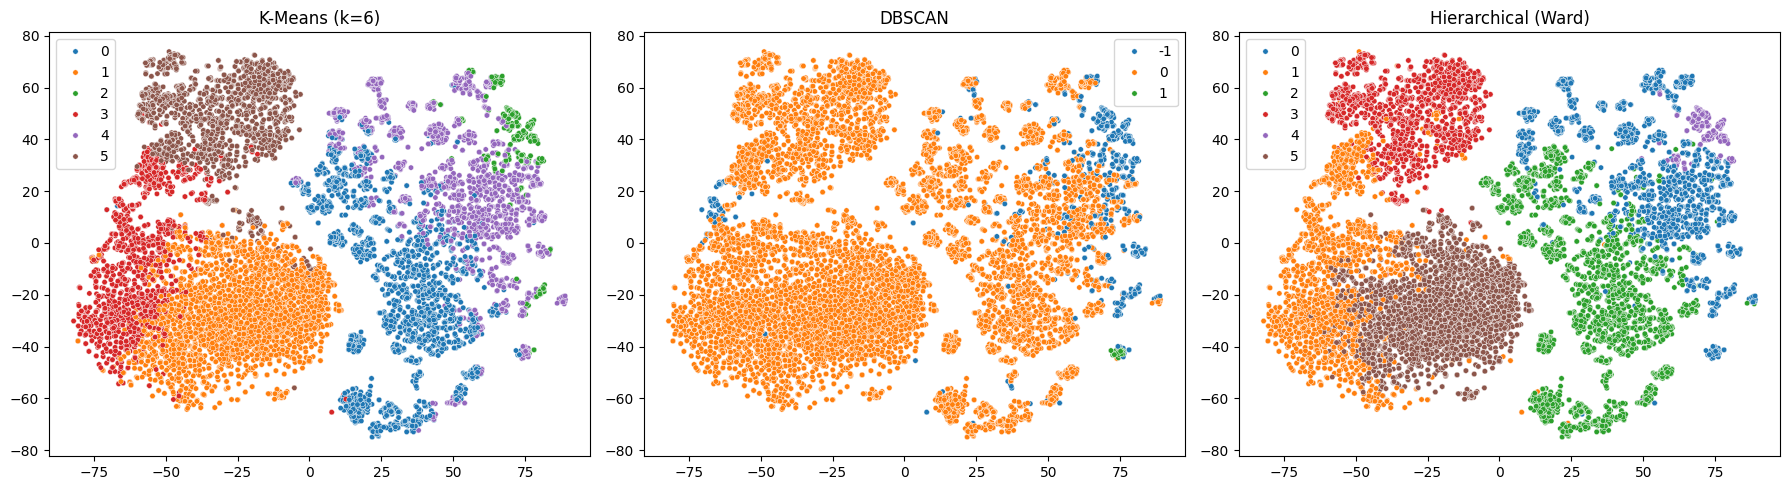

In [14]:
plt.figure(figsize=(18, 5))

# K-Means
plt.subplot(1, 3, 1)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette='tab10', s=15, legend='full')
plt.title('K-Means (k=6)')

# DBSCAN
plt.subplot(1, 3, 2)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=dbscan_labels, palette='tab10', s=15, legend='full')
plt.title('DBSCAN')

# Hierarchical
plt.subplot(1, 3, 3)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=hac_labels, palette='tab10', s=15, legend='full')
plt.title('Hierarchical (Ward)')

plt.tight_layout()
plt.show()

## 7. Observations and Comparative Analysis

**1. Which algorithm produced the most meaningful clusters? Why?**
Both **K-Means** and **Hierarchical Clustering (Ward)** produced the most meaningful clusters. When k=6, they successfully identified clusters roughly corresponding to the underlying distinct static and dynamic groupings. Looking at the Adjusted Rand Index (ARI) and NMI scores, K-Means and HAC perform equivalently well compared to ground truth labels. DBSCAN failed to produce meaningful clusters that correlated to human activities as it either classified large chunks of points as a single dense blob or relegated a lot of points to noise.

**2. How sensitive was K-Means to the choice of k?**
K-Means was highly sensitive to the choice of k. The optimal k determined by the Silhouette score was heavily in favor of `k=2` because the data physically exists in two main "super-clusters" (Static vs. Dynamic actions). Selecting `k=6` lowers the Silhouette score due to the merging/confusion of strongly overlapping classes like Sitting and Standing.

**3. Did DBSCAN detect noise or small clusters effectively?**
DBSCAN had immense difficulty cleanly separating clusters due to the varying density across classes and the high-dimensional nature of the data (curse of dimensionality), even when scaled and dimensionally reduced. Depending on the `eps` configuration, it either lumped the distinct clusters into one giant super-cluster or flagged a huge proportion of non-core boundary points as noise. It is less effective here compared to K-Means and HAC.

**4. How does linkage choice (single/complete/ward) affect hierarchical clustering?**
* **Ward's** linkage minimizes intra-cluster variance, leading to compact, tightly bound spherical clusters (much like K-Means) which effectively partition overlapping datasets like HAR.
* **Single** linkage usually suffers severely from "chaining", linking everything into elongated threads that don't match categorical clusters.
* **Complete** linkage can be overly sensitive to outliers, sometimes forcing uneven cluster sizes. Ward is overwhelmingly the best robust choice for dense, overlapping groups.

**5. Which internal metric best matched your visual intuition of cluster quality?**
The **Silhouette Score** most clearly matched the visual intuition provided by the t-SNE plot. t-SNE distinctively rendered two gargantuan clusters separating active behaviors from static positions. The Silhouette Score intuitively maximized at `k=2`, correctly identifying that the most mathematically distinct separation was between those two super-clusters, rather than the six overlapping activity sub-labels.